In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
# Đọc dữ liệu 
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

In [2]:
# 1. Tải và Tiền xử lý dữ liệu (Data Preprocessing)
# Tạo ma trận X 
    # Loại bỏ đơn hủy và xử lý ngày tháng
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)
    
    # Loại bỏ dữ liệu thiếu và giá trị <= 0
df = df.dropna(subset=['CustomerID'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
    
    # Tính TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']   
    
print("Kích thước tập dữ liệu sau khi xử lý:", df.shape)
df

Kích thước tập dữ liệu sau khi xử lý: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [3]:
# 2. Tạo đặc trưng RFM (Feature Engineering)
snapshot_date = df['InvoiceDate'].max() + pd.to_timedelta(1, unit='d')
rfm = df.groupby(['CustomerID']).agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalPrice': 'Monetary'}, inplace=True)

In [4]:
# 3. TỐI ƯU HÓA: Xử lý phân phối lệch (Log Transformation)
    # Áp dụng np.log1p (log(1+x)) để xử lý số 0 và giảm độ lệch của dữ liệu
rfm_log = np.log1p(rfm)

In [5]:
# 4. Chuẩn hóa dữ liệu (Scaling)
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)

In [6]:
# 5. Hàm in các ma trận cần thiết cho phân cụm đa cấp
def in_cac_ma_tran(X_data):
    # 1. Ma trận khoảng cách (Distance Matrix)
    # Tính khoảng cách giữa từng cặp điểm (Pairwise Distance)
    # Lưu ý: Với dữ liệu lớn, ma trận này rất lớn. Ở đây chỉ in 5x5 phần tử đầu tiên.
    dist_matrix_condensed = pdist(X_data, metric='euclidean')
    dist_matrix_full = squareform(dist_matrix_condensed)
    
    print("--- 1. MA TRẬN KHOẢNG CÁCH (5x5 phần tử đầu) ---")
    print("Mô tả: Khoảng cách Euclidean giữa các khách hàng.")
    print(pd.DataFrame(dist_matrix_full).iloc[:5, :5])
    print("\n")

    # 2. Ma trận liên kết (Linkage Matrix)
    # Đây là input trực tiếp để vẽ Dendrogram
    # method='ward' là phương pháp được khuyến nghị cho bài toán này
    linkage_matrix = linkage(X_data, method='ward', metric='euclidean')

    print("--- 2. MA TRẬN LIÊN KẾT (LINKAGE MATRIX) ---")
    print("Mô tả: Các bước gộp cụm. Cấu trúc 4 cột: [Cụm A, Cụm B, Khoảng cách, Số phần tử mới]")
    # In 10 bước gộp đầu tiên
    print("10 bước gộp đầu tiên:")
    print(linkage_matrix[:10])
     # In 10 bước gộp cuối cùng
    print("\n10 bước gộp cuối cùng:")
    print(linkage_matrix[-10:])
    
    return linkage_matrix

Z = in_cac_ma_tran(X)

--- 1. MA TRẬN KHOẢNG CÁCH (5x5 phần tử đầu) ---
Mô tả: Khoảng cách Euclidean giữa các khách hàng.
          0         1         2         3         4
0  0.000000  5.528552  3.878243  4.661734  4.668659
1  5.528552  0.000000  2.871448  1.742668  4.422486
2  3.878243  2.871448  0.000000  1.200916  1.760884
3  4.661734  1.742668  1.200916  0.000000  2.684658
4  4.668659  4.422486  1.760884  2.684658  0.000000


--- 2. MA TRẬN LIÊN KẾT (LINKAGE MATRIX) ---
Mô tả: Các bước gộp cụm. Cấu trúc 4 cột: [Cụm A, Cụm B, Khoảng cách, Số phần tử mới]
10 bước gộp đầu tiên:
[[1.37700000e+03 3.11400000e+03 8.74020540e-04 2.00000000e+00]
 [1.63800000e+03 2.66700000e+03 1.35430731e-03 2.00000000e+00]
 [2.75000000e+02 3.96400000e+03 3.64595089e-03 2.00000000e+00]
 [4.89000000e+02 1.11700000e+03 4.16935782e-03 2.00000000e+00]
 [7.70000000e+01 1.47500000e+03 4.36440939e-03 2.00000000e+00]
 [2.15500000e+03 3.90500000e+03 6.26912190e-03 2.00000000e+00]
 [1.51700000e+03 2.06100000e+03 6.39079414e-03 2.00000000

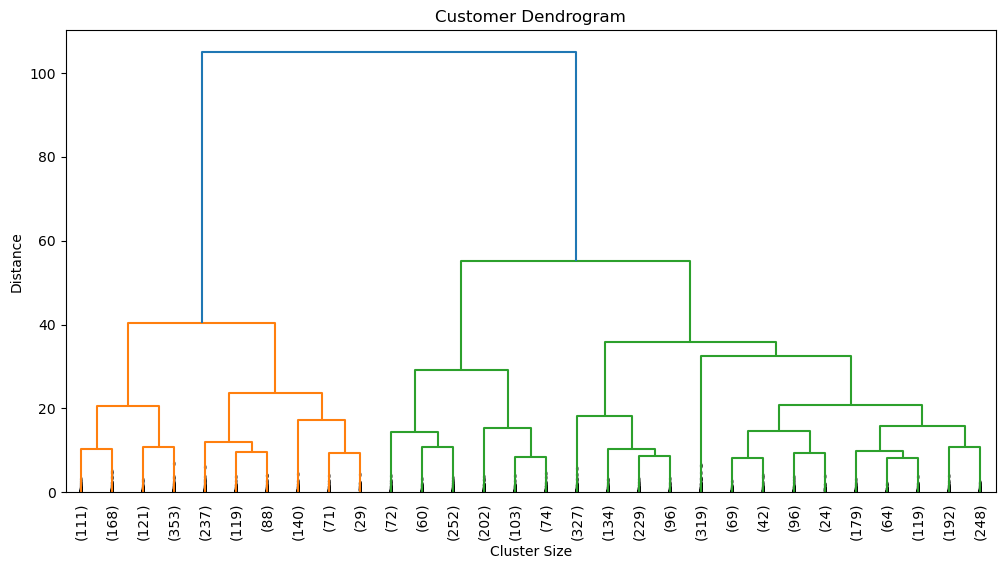

In [7]:
# 6. Phân cụm đa cấp với dữ liệu đã tối ưu
plt.figure(figsize=(12, 6))
plt.title("Customer Dendrogram")

    # Vẽ dendrogram trực tiếp từ ma trận Z
dendrogram(
    Z,
    truncate_mode='lastp',  # Chỉ hiển thị p nhánh cuối cùng để biểu đồ gọn hơn
    p=30,                   # Số lượng nhánh hiển thị
    leaf_rotation=90.,      # Xoay nhãn trục hoành 90 độ
    leaf_font_size=10.,     # Cỡ chữ nhãn
    show_contracted=True    # Hiển thị dấu gạch thể hiện các điểm bị ẩn trong nhánh
)

plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

Silhouette Score (Optimized): 0.2608


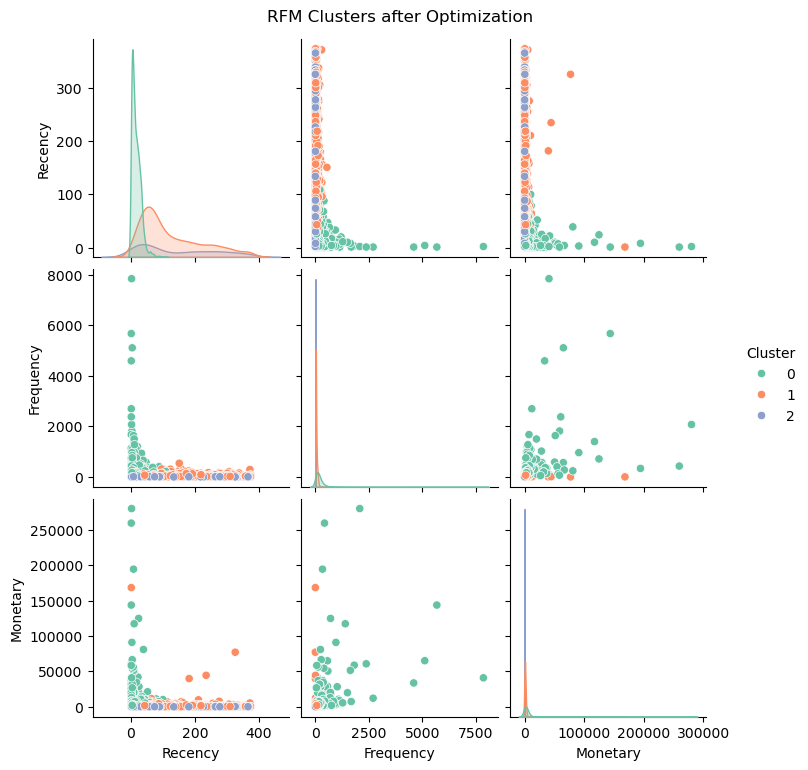

In [ ]:
# 7. Đánh giá và Trực quan hóa
    # Chọn k=3 (hoặc số khác dựa trên dendrogram)
k = 3
ac = AgglomerativeClustering(n_clusters=k, linkage='ward')
rfm['Cluster'] = ac.fit_predict(X)

score = silhouette_score(X, rfm['Cluster'])
print(f"Silhouette Score (Optimized): {score:.4f}")
sns.pairplot(rfm, hue='Cluster', vars=['Recency', 'Frequency', 'Monetary'], palette='Set2')
plt.suptitle("RFM Clusters after Optimization", y=1.02)
plt.show()

In [9]:
 # Thống kê trung bình thực tế (trên dữ liệu gốc)
print("\nTrung bình các chỉ số RFM theo cụm:")
print(rfm.groupby('Cluster').mean().round(2))


Trung bình các chỉ số RFM theo cụm:
         Recency  Frequency  Monetary
Cluster                              
0          16.12     202.94   4540.30
1         125.27      46.96   1041.28
2         144.74       7.68    210.65
